In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

import mpscr_models as mpscr
import pwexp
import gndr_utils as utils
import mps

E0000 00:00:1783537498.677609   28366 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783537498.682668   28366 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783537498.696499   28366 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783537498.696526   28366 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783537498.696527   28366 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783537498.696529   28366 computation_placer.cc:177] computation placer already registered. Please check linka

Thetaflow version: 0.0.35


I0000 00:00:1783537501.388583   28366 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4382 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1783537501.427134   28366 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4382 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1783537501.463372   28366 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4382 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1783537501.464476   28366 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4382 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1783537501.466180   28366 gpu_device.cc:2019] Cr

In [2]:
a0 = 1.0
p_min = 0.0
p_max = 1.0
sup = np.arange(501)

def log_a(m, q):
    return -tf.math.lgamma(m+1)

def a(m, q):
    return tf.math.exp( log_a(m, q) )

# For the Poisson, a0 is always equal to 1.0, as there is no second parameter, q
def a0(q):
    return 1.0

def phi(theta, q):
    return tf.identity(theta)

def log_phi(theta, q):
    return tf.math.log(theta)
                       
def phi_inv(u, q):
    return tf.identity(u)

def C(theta, q):
    return tf.math.exp(theta)

def C_inv(u, q):
    return tf.math.log(u)

def A(u, q):
    theta = phi_inv(u, q)
    return C(theta, q)

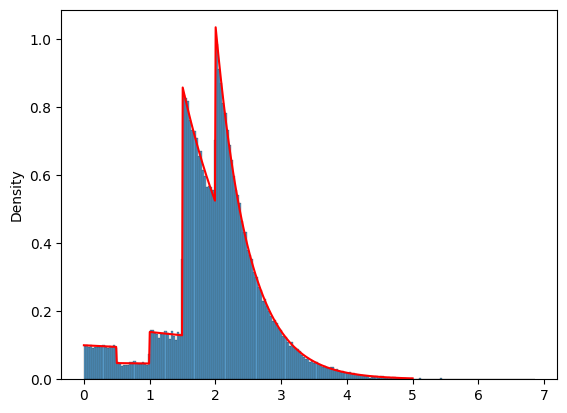

In [3]:
alpha = np.array([0.1, 0.05, 0.15, 1, 2])
s = np.array([0,0.5,1,1.5,2])
t = np.linspace(0.001, 5, 500)

h_t = pwexp.h(t, alpha, s)
H_t = pwexp.ch(t, alpha, s)
F_t = pwexp.cdf(t, alpha, s, lower_tail = True)
f_t = pwexp.pdf(t, alpha, s)
F_inv_t = pwexp.ppf(F_t, alpha, s)

sample_t = pwexp.rvs(alpha, s, size = 100000)

sns.histplot(x = sample_t, stat = "density")
plt.plot(t, f_t, color = "red")
# plt.plot(t, F_t)
# plt.plot(F_t, F_inv_t)
# plt.plot([0,np.max(t)], [0, np.max(t)])
plt.show()

To validate the implementation of our general model, we consider a simple data generating scheme with a single predictor variable, $x$.

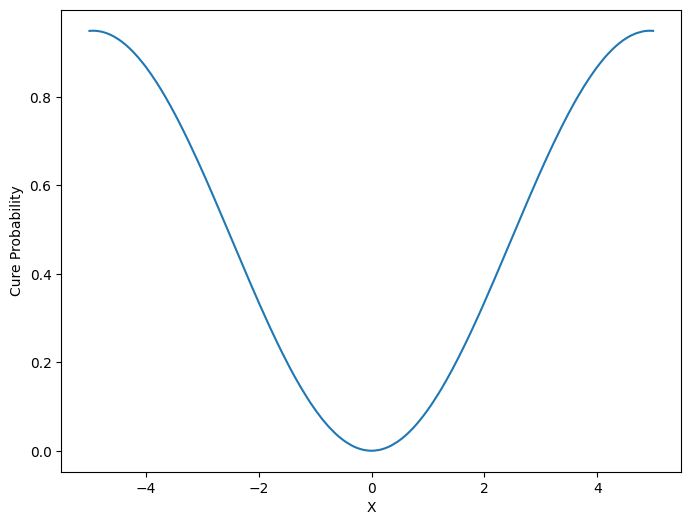

In [4]:
n = 500

x = np.random.uniform(size = n, low = -5.0, high = 5.0)

# beta0 = -3
# beta1 = 2
# linear_x = beta0 + beta1 * x
# p_true = 1/(1+np.exp(-linear_x))
p_true = np.sin(x / np.pi)**2 * 0.95

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))
sns.lineplot(x = x, y = p_true, ax = ax)
ax.set_xlabel("X")
ax.set_ylabel("Cure Probability")
plt.show()

We consider the latent variables to follow a Poisson distribution merged with a standard Exp(1) distribution as a base distribution, $S_0$.

In [5]:
np.random.seed(10)

n = 1000

x = np.random.uniform(size = n, low = -5.0, high = 5.0)
# beta0 = -3
# beta1 = 2
# linear_x = beta0 + beta1 * x
# p_true = 1/(1+np.exp(-linear_x))
p_true = np.sin(x / np.pi)**2 * 0.95

# theta = C^{-1}( a0 / p )
# For the Poisson, we have C(theta) = e^theta, a0 = 1.0
theta = np.log( 1.0 / p_true )
q = 0.0

# m = np.random.poisson(size = n, lam = theta)
m = mps.rvs(log_a, log_phi, theta, q, sup).numpy()
cured = (m == 0).astype("int")

# Random uniform generators for the true lifetimes
u = np.random.uniform(size = np.sum(m > 0) )
# True lifetimes
y_true = np.repeat(np.inf, n)
y_true[m > 0] = -np.log(1 - u**(1/m[m > 0])) / theta[m > 0]
y_censor = np.random.uniform(size = n, low = 0.0, high = 5.0)

y = y_true.copy()
delta = np.repeat(0, n)
# Define observed lifetimes as 1
delta[y_true <= y_censor] = 1
# Censor lifetimes greater than censorship times
y[y_true > y_censor] = y_censor[y_true > y_censor]

print("Proportion of censored: {:.2f}%".format( (1-np.mean(delta))*100 ))

Proportion of censored: 61.90%


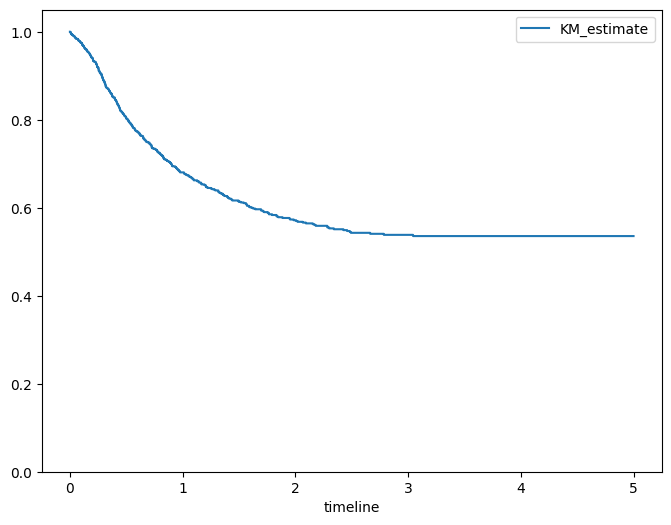

In [6]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(y, delta)
km.plot(ax = ax, ci_show = False, show_censors = False)
ax.set_ylim(0,1.05)

plt.show()

In [7]:
data = [y, delta]

poisson_spec = mpscr.MPSPoisson()
with tf.device("/CPU:0"):
    poisson_model = mpscr.build_mpscr_model(y, delta, (1,), poisson_spec, seed = 10, n_cuts = 5)
    poisson_model.pre_train_model(epochs = None, x = x[:,None], data = data, shuffle = True)
    poisson_model.train_model(epochs = 5000, x = x[:,None], data = data,
                              shuffle = True,
                              get_covariances = False,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.01),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 275 / 5000 ]  | Avg. Train NLL:  0.541017532 | Avg. Validation NLL:  0.533188939 | Best Avg. Validation NLL:  0.532979965 | Speed:  0.00225250493  epoch/s    | Elapsed Time:  0.619438887  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 68 / 5000 ]  | Avg. Train NLL:  0.54187566 | Best Avg. Train NLL:  0.54187566 | Avg. Validation NLL:  0.533525586 | Speed:  0.0017896645  epoch/s    | Elapsed Time:  0.121697187  s       
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 10.235 seconds.


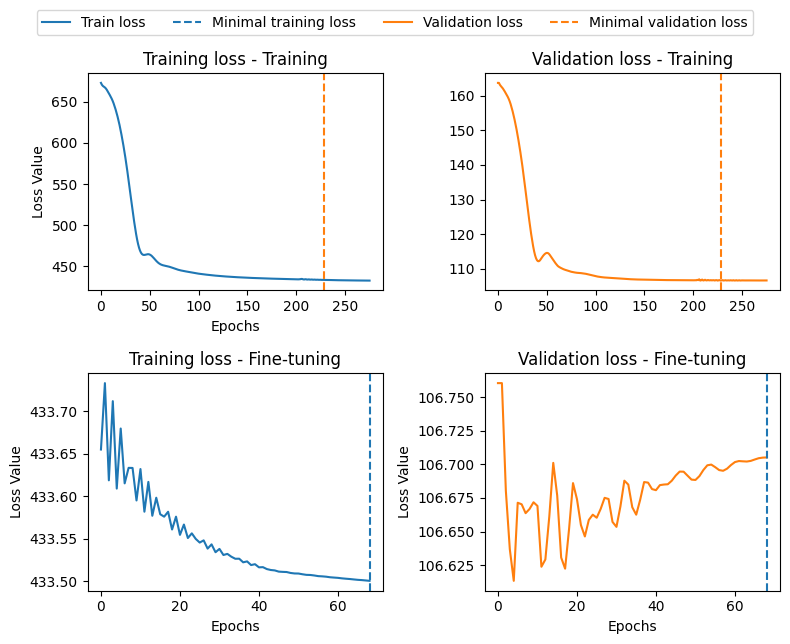

In [8]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (8,6))

utils.plot_model_convergence( poisson_model, ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1] )

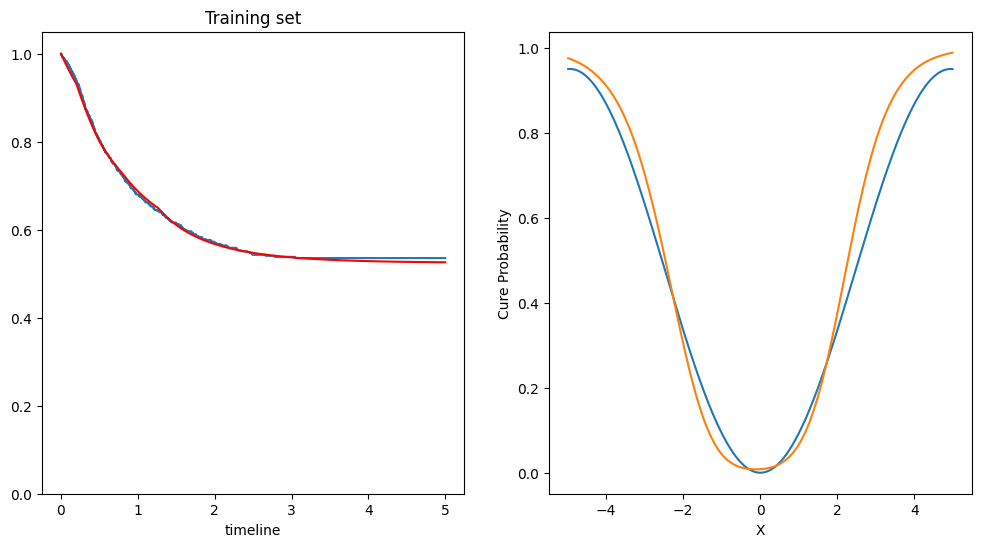

In [9]:
results_cure_poisson = poisson_model.get_survival_cure(y, x[:,None], y, x[:,None], ngrid = 100)

t = np.linspace(0.0001, np.max(y), 100)[:, None]

alpha_pred = poisson_model.predict("alpha")
p_pred = poisson_model.predict(x)["p"].numpy().flatten()
p_pred = tf.clip_by_value(p_pred, 1.0e-5, 1-1.0e-5)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

utils.average_kaplan_meier(results_cure_poisson["ts_grid"], results_cure_poisson["S_ts_train"],
                           y, delta, show_individual = False, ax = ax[0])
ax[0].get_legend().remove()

sns.lineplot(x = x, y = p_true, ax = ax[1])
sns.lineplot(x = x, y = p_pred, ax = ax[1])
ax[1].set_xlabel("X")
ax[1].set_ylabel("Cure Probability")

plt.show()